# 🧠 Brain Tumor Detection — MRI Image Classification (EfficientNet-B0 Transfer Learning)

**Pipeline:** Data Acquisition → Augmentation → Model Architecture → Training → Evaluation → Deployment

**Target:** 90–98% test accuracy using EfficientNet-B0 transfer learning (PyTorch) with a two‑phase freeze/fine‑tune strategy, class‑imbalance handling, and Grad‑CAM interpretability.

**How to use in Google Colab:**
1. Runtime → Change runtime type → **GPU (T4 or better)**.
2. Upload your dataset zip to Google Drive (e.g. `MyDrive/brain_tumor_dataset.zip`). The zip should contain one folder per class, e.g.:
```
brain_tumor_dataset.zip
├── glioma/
├── meningioma/
├── pituitary/
└── notumor/
```
(Works with the common Kaggle 4-class brain tumor MRI dataset, or a 2-class tumor/no-tumor dataset — the code auto-detects the number of classes.)
3. Update the `DATASET_ZIP_PATH` variable in **Phase 1** to point to your zip file.
4. Run all cells top to bottom (`Runtime → Run all`).


## ⚙️ Setup — Install & Import Libraries

In [1]:

!pip install -q torch torchvision torchmetrics grad-cam scikit-learn seaborn tqdm --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 30.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s et

In [2]:

import os, shutil, random, zipfile, time, copy, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 📁 PHASE 1 — Data Acquisition & Preprocessing
**Goal:** Prepare a clean, split, and normalized dataset from the zip file stored in Google Drive.


In [3]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

# ============ EDIT THIS PATH ============
DATASET_ZIP_PATH = "/content/drive/MyDrive/Tumor_Dataset/Brain_tumor.zip"   # <-- path to your zip file in Drive
# =========================================

EXTRACT_DIR   = "/content/data_raw"        # raw extracted classes
SPLIT_DIR     = "/content/data_split"      # train/val/test organized data
IMG_SIZE      = 224
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

assert os.path.exists(DATASET_ZIP_PATH), f"Zip not found at {DATASET_ZIP_PATH}. Update DATASET_ZIP_PATH."

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print("Extracted to", EXTRACT_DIR)


Extracted to /content/data_raw


In [5]:
# Auto-locate the folder that actually contains the class subfolders
# (handles the case where the zip has a single wrapper folder inside it)
def find_class_root(root):
    for dirpath, dirnames, filenames in os.walk(root):
        subdirs = [d for d in dirnames if not d.startswith('.') and not d.startswith('__')]
        if len(subdirs) >= 2:
            # check these subdirs actually contain images
            sample = os.path.join(dirpath, subdirs[0])
            has_images = any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in os.listdir(sample))
            if has_images:
                return dirpath, sorted(subdirs)
    raise RuntimeError("Could not auto-detect class folders. Check zip structure.")

CLASS_ROOT, CLASS_NAMES = find_class_root(EXTRACT_DIR)
NUM_CLASSES = len(CLASS_NAMES)
print("Class root:", CLASS_ROOT)
print(f"Detected {NUM_CLASSES} classes: {CLASS_NAMES}")


Class root: /content/data_raw/Training
Detected 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:

# Organize into train/val/test class folders (stratified split)
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

counts = {}
for cls in CLASS_NAMES:
    src_dir = os.path.join(CLASS_ROOT, cls)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    counts[cls] = len(files)

    train_files, temp_files = train_test_split(files, test_size=(1 - TRAIN_RATIO), random_state=SEED)
    val_files, test_files = train_test_split(
        temp_files, test_size=TEST_RATIO / (TEST_RATIO + VAL_RATIO), random_state=SEED)

    for split, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
        for f in split_files:
            shutil.copy(os.path.join(src_dir, f), os.path.join(SPLIT_DIR, split, cls, f))

print("Images per class (original):")
for k, v in counts.items():
    print(f"  {k}: {v}")

for split in ["train", "val", "test"]:
    total = sum(len(os.listdir(os.path.join(SPLIT_DIR, split, c))) for c in CLASS_NAMES)
    print(f"{split}: {total} images")


Images per class (original):
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400
train: 3916 images
val: 840 images
test: 844 images


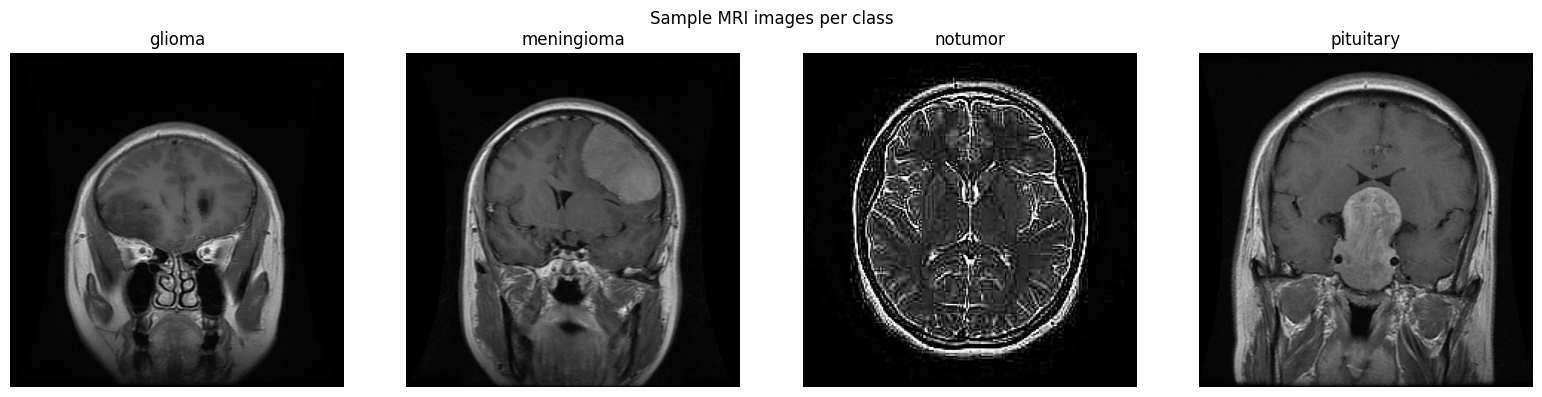

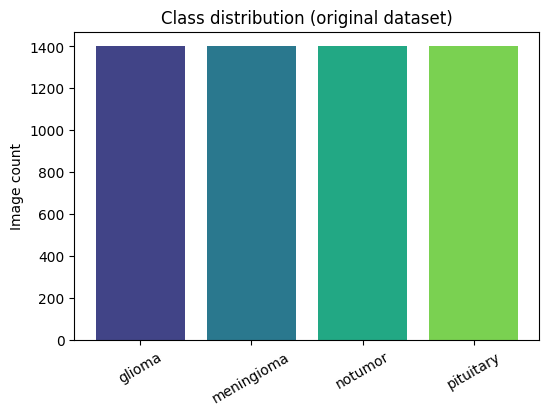

In [12]:
# Visual sanity check + class distribution plot
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
if NUM_CLASSES == 1:
    axes = [axes]
for ax, cls in zip(axes, CLASS_NAMES):
    folder = os.path.join(SPLIT_DIR, "train", cls)
    fname = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample MRI images per class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=sns.color_palette("viridis", NUM_CLASSES))
plt.title("Class distribution (original dataset)")
plt.ylabel("Image count")
plt.xticks(rotation=30)
plt.show()


## 🔄 PHASE 2 — Dataset & Augmentation
**Goal:** Create a PyTorch `Dataset`/`DataLoader` with augmentation and handle class imbalance via a weighted sampler + class weights (used later in the loss function).


In [13]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.15),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [14]:

class BrainTumorDataset(Dataset):
    '"\"\"\"Custom Dataset that reads MRI images from a class-organized folder.\"\"\"'
    def __init__(self, root_dir, class_names, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        for cls in class_names:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = BrainTumorDataset(os.path.join(SPLIT_DIR, "train"), CLASS_NAMES, train_transform)
val_dataset   = BrainTumorDataset(os.path.join(SPLIT_DIR, "val"),   CLASS_NAMES, val_test_transform)
test_dataset  = BrainTumorDataset(os.path.join(SPLIT_DIR, "test"),  CLASS_NAMES, val_test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 3916 | Val: 840 | Test: 844


In [15]:
# Handle class imbalance: class weights (for loss) + weighted sampler (for balanced batches)
train_labels = [label for _, label in train_dataset.samples]
class_sample_counts = np.array([train_labels.count(i) for i in range(NUM_CLASSES)])
print("Train samples per class:", dict(zip(CLASS_NAMES, class_sample_counts)))

class_weights = class_sample_counts.sum() / (NUM_CLASSES * class_sample_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights (for loss):", dict(zip(CLASS_NAMES, np.round(class_weights, 3))))

sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


Train samples per class: {'glioma': np.int64(979), 'meningioma': np.int64(979), 'notumor': np.int64(979), 'pituitary': np.int64(979)}
Class weights (for loss): {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}


In [16]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoaders ready:", len(train_loader), "train batches |", len(val_loader), "val batches |",
      len(test_loader), "test batches")


DataLoaders ready: 123 train batches | 27 val batches | 27 test batches


## 🏗️ PHASE 3 — Model Architecture (Transfer Learning)
**Goal:** Build a trainable model using **EfficientNet-B0** pretrained on ImageNet, with a custom classification head, using a freeze → fine-tune strategy.


In [17]:
def build_model(num_classes, dropout=0.3):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze the backbone (feature extractor) initially
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(p=dropout / 2),
        nn.Linear(256, num_classes),
    )
    return model.to(DEVICE)

model = build_model(NUM_CLASSES)
print(model.classifier)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable params (Phase A, frozen backbone): {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (4): Dropout(p=0.15, inplace=False)
  (5): Linear(in_features=256, out_features=4, bias=True)
)
Total params: 4,337,024 | Trainable params (Phase A, frozen backbone): 329,476


In [18]:
class FocalLoss(nn.Module):
    """Focal Loss — down-weights easy examples, helps with class imbalance."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

## 🏋️ PHASE 4 — Training & Validation
**Goal:** Train the model with a two-phase strategy (frozen head → fine-tuned full network), track metrics, apply early stopping, and save the best-performing checkpoint.


In [19]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_train):   # <-- scoped context manager, not a global statement
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 num_epochs, patience, ckpt_path):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        t0 = time.time()
        train_loss, train_acc, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc); history["val_f1"].append(val_f1)

        print(f"Epoch {epoch+1}/{num_epochs} ({time.time()-t0:.1f}s) | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            epochs_no_improve = 0
            print(f"  ✅ New best model saved (val_loss={val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  ⏹ Early stopping triggered after {epoch+1} epochs.")
                break

    model.load_state_dict(best_state)
    return model, history


### Phase 4A — Train the classification head (backbone frozen)

In [20]:
BEST_MODEL_PATH = "/content/best_model.pth"

model, history_a = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=10, patience=4, ckpt_path=BEST_MODEL_PATH
)


  0%|          | 0/123 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 1/10 (46.6s) | Train Loss 0.2971 Acc 0.7722 | Val Loss 0.1590 Acc 0.8607 F1 0.8564
  ✅ New best model saved (val_loss=0.1590)


  0%|          | 0/123 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

...

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 9/10 (41.2s) | Train Loss 0.1489 Acc 0.8506 | Val Loss 0.1003 Acc 0.9000 F1 0.8997


  0%|          | 0/123 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 10/10 (42.8s) | Train Loss 0.1404 Acc 0.8578 | Val Loss 0.0925 Acc 0.9095 F1 0.9096


### Phase 4B — Unfreeze backbone and fine-tune end-to-end (lower learning rate)

In [21]:
# Unfreeze the last few blocks of EfficientNet-B0 for fine-tuning (cheaper & less prone to overfitting
# than unfreezing everything). Change `unfreeze_from` to 0 to unfreeze the whole backbone.
unfreeze_from = 5   # EfficientNet-B0 has 9 feature blocks (0-8); unfreeze the later ones
for i, child in enumerate(model.features.children()):
    if i >= unfreeze_from:
        for param in child.parameters():
            param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params (Phase B, fine-tuning): {trainable_params:,}")

fine_tune_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                         lr=1e-5, weight_decay=1e-4)
fine_tune_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer, mode='min', factor=0.5, patience=3)

model, history_b = train_model(
    model, train_loader, val_loader, criterion, fine_tune_optimizer, fine_tune_scheduler,
    num_epochs=20, patience=6, ckpt_path=BEST_MODEL_PATH
)


Trainable params (Phase B, fine-tuning): 4,028,364


  0%|          | 0/123 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 1/20 (47.6s) | Train Loss 0.1243 Acc 0.8751 | Val Loss 0.0877 Acc 0.9143 F1 0.9141
  ✅ New best model saved (val_loss=0.0877)


  0%|          | 0/123 [00:00<?, ?it/s]

...

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 19/20 (43.5s) | Train Loss 0.0817 Acc 0.9093 | Val Loss 0.0580 Acc 0.9452 F1 0.9454


  0%|          | 0/123 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 20/20 (45.7s) | Train Loss 0.0818 Acc 0.9150 | Val Loss 0.0545 Acc 0.9440 F1 0.9441


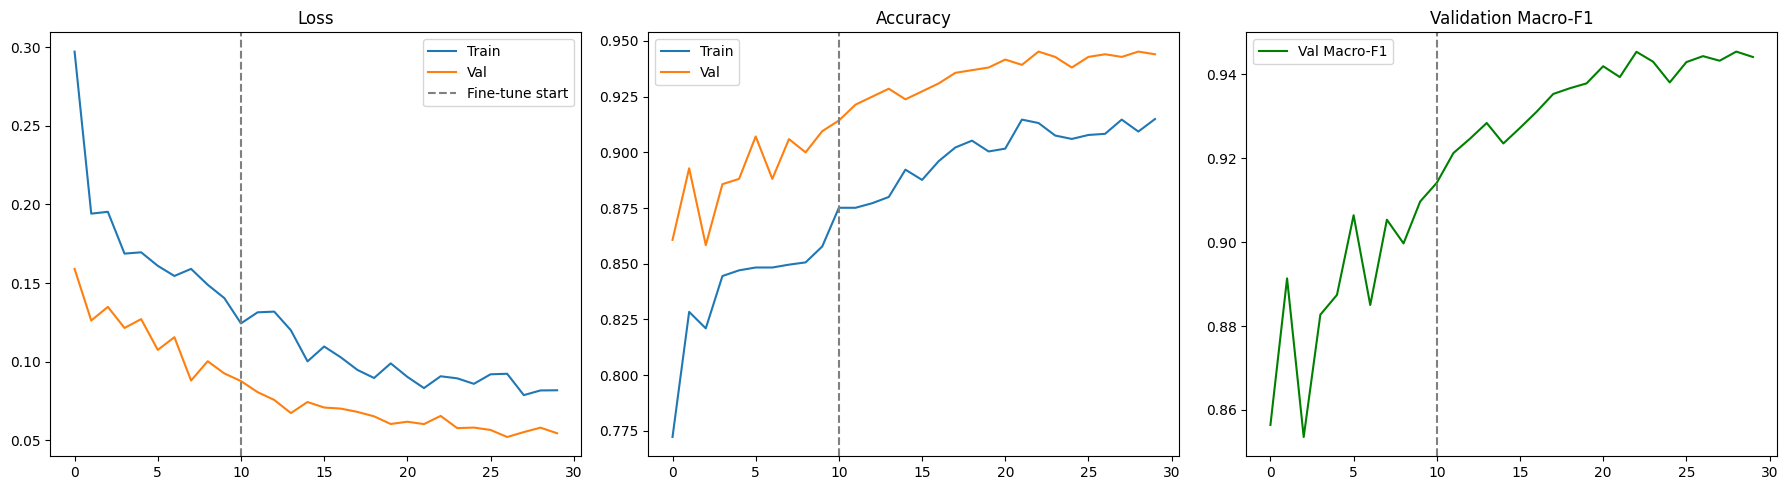

Loaded best model checkpoint from /content/best_model.pth


In [22]:
# Combine training history from both phases and plot
history = {k: history_a[k] + history_b[k] for k in history_a}
switch_epoch = len(history_a["train_loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
axes[0].axvline(switch_epoch, color='gray', linestyle='--', label="Fine-tune start")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train"); axes[1].plot(history["val_acc"], label="Val")
axes[1].axvline(switch_epoch, color='gray', linestyle='--')
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(history["val_f1"], label="Val Macro-F1", color='green')
axes[2].axvline(switch_epoch, color='gray', linestyle='--')
axes[2].set_title("Validation Macro-F1"); axes[2].legend()

plt.tight_layout()
plt.savefig("/content/training_history.png", dpi=150)
plt.show()

# Load the best checkpoint from either phase
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
print("Loaded best model checkpoint from", BEST_MODEL_PATH)


## 📊 PHASE 5 — Evaluation & Explainable AI
**Goal:** Evaluate the trained model on the held-out test set and explain its predictions with Grad-CAM.


In [23]:

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average='macro')
test_recall = recall_score(all_labels, all_preds, average='macro')
test_f1 = f1_score(all_labels, all_preds, average='macro')

try:
    if NUM_CLASSES == 2:
        test_auc = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
        test_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
except Exception as e:
    test_auc = None
    print("AUC could not be computed:", e)

print("="*50)
print(f"TEST ACCURACY : {test_acc*100:.2f}%")
print(f"TEST PRECISION: {test_precision*100:.2f}%")
print(f"TEST RECALL   : {test_recall*100:.2f}%")
print(f"TEST F1-SCORE : {test_f1*100:.2f}%")
if test_auc is not None:
    print(f"TEST AUC      : {test_auc*100:.2f}%")
print("="*50)


  0%|          | 0/27 [00:00<?, ?it/s]

TEST ACCURACY : 93.01%
TEST PRECISION: 93.16%
TEST RECALL   : 93.01%
TEST F1-SCORE : 93.03%
TEST AUC      : 99.16%


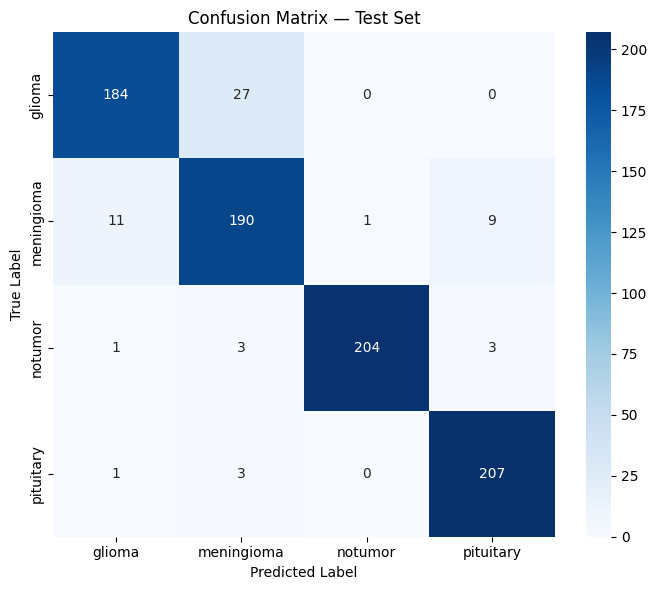


Classification Report:

              precision    recall  f1-score   support

      glioma     0.9340    0.8720    0.9020       211
  meningioma     0.8520    0.9005    0.8756       211
     notumor     0.9951    0.9668    0.9808       211
   pituitary     0.9452    0.9810    0.9628       211

    accuracy                         0.9301       844
   macro avg     0.9316    0.9301    0.9303       844
weighted avg     0.9316    0.9301    0.9303       844



In [24]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))


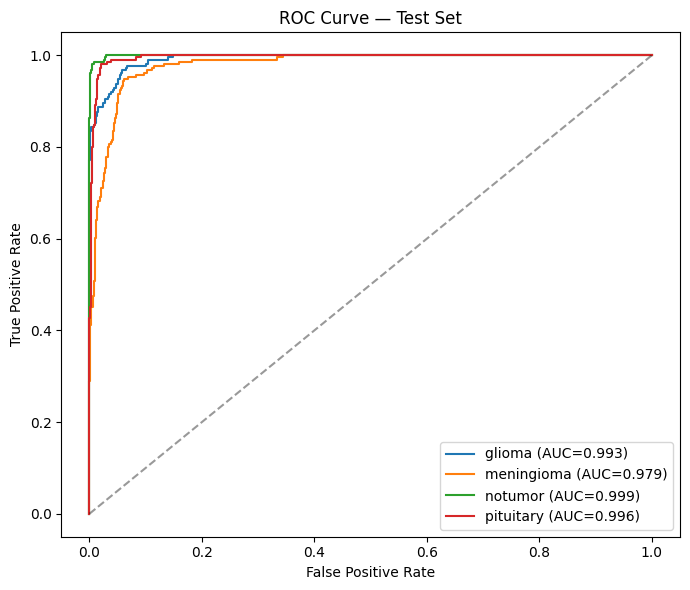

In [25]:
# ROC curves (one-vs-rest for multi-class, standard ROC for binary)
plt.figure(figsize=(7, 6))
if NUM_CLASSES == 2:
    fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
else:
    y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("/content/roc_curve.png", dpi=150)
plt.show()


In [ ]:
torch.set_grad_enabled(True)   # make sure gradients are enabled before Grad-CAM

torch.autograd.grad_mode.set_grad_enabled(mode=True)

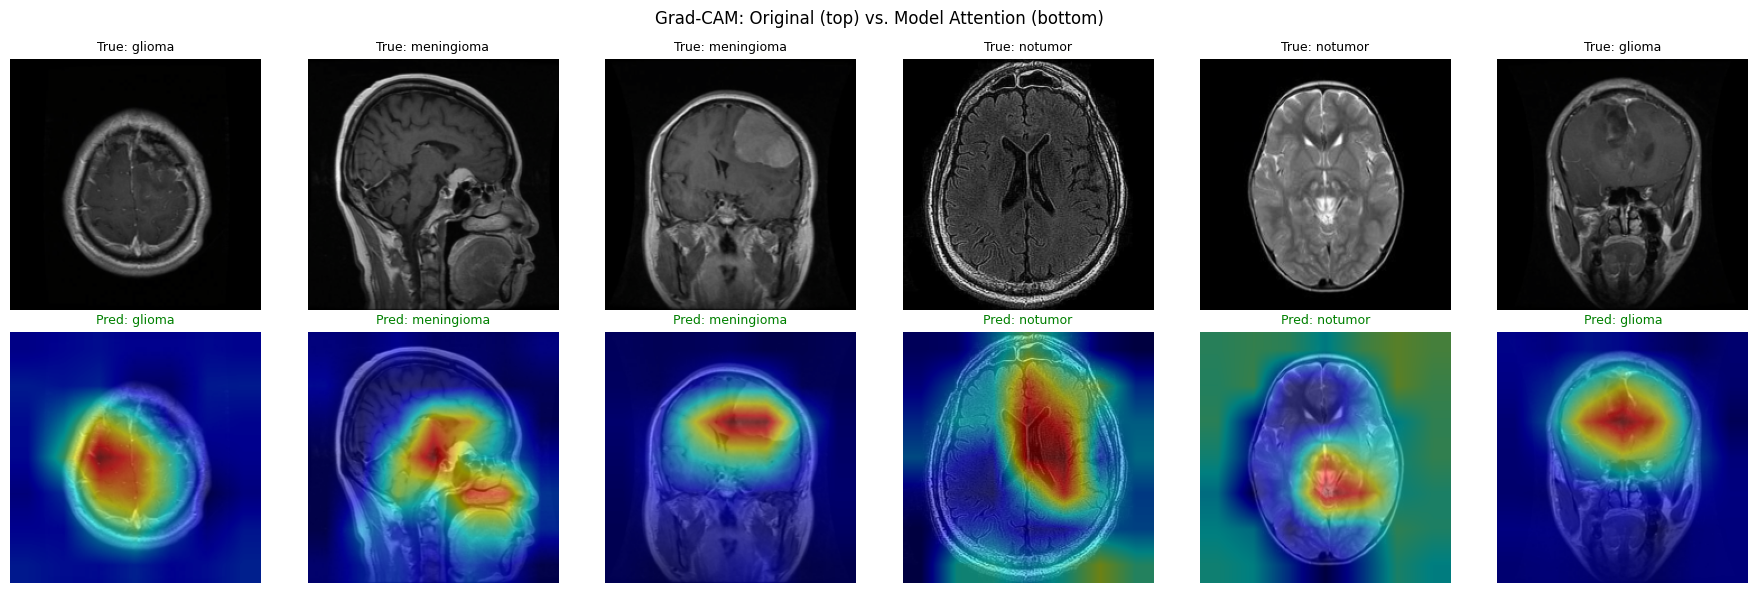

In [29]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import random # Import random module

torch.set_grad_enabled(True)   # ensure grad mode is on (Grad-CAM needs backprop)

target_layer = [model.features[-1]]   # last conv block of EfficientNet-B0
cam = GradCAM(model=model, target_layers=target_layer)

def denormalize(tensor_img):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

# Grab a handful of random test images to visualize
n_show = min(6, len(test_dataset)) # Ensure we don't try to show more images than available
random_indices = random.sample(range(len(test_dataset)), n_show) # Select random indices

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
# Handle the case where n_show is 1, as plt.subplots(2, 1) returns a 1D array for axes
if n_show == 1:
    axes = np.expand_dims(axes, axis=1)

for i, idx in enumerate(random_indices):
    # Get the transformed image tensor and its true label directly from the dataset
    img_tensor_for_model, true_label = test_dataset[idx]

    # Prepare input tensor for the model (add batch dimension and move to device)
    input_tensor = img_tensor_for_model.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        pred_label = torch.argmax(output, dim=1).item()

    # Generate Grad-CAM heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_label)])[0]

    # Denormalize the image tensor for display
    rgb_img = denormalize(img_tensor_for_model)

    # Overlay heatmap on the original image
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Display original image
    axes[0, i].imshow(rgb_img); axes[0, i].axis("off")
    axes[0, i].set_title(f"True: {CLASS_NAMES[true_label]}", fontsize=9)

    # Display Grad-CAM result
    axes[1, i].imshow(visualization); axes[1, i].axis("off")
    color = "green" if pred_label == true_label else "red"
    axes[1, i].set_title(f"Pred: {CLASS_NAMES[pred_label]}", fontsize=9, color=color)

plt.suptitle("Grad-CAM: Original (top) vs. Model Attention (bottom)")
plt.tight_layout()
plt.savefig("/content/gradcam_examples.png", dpi=150)
plt.show()

# Quick Single-Image Check

Test the trained model on **any single MRI image** - either a path you already have, or one you upload - before moving on to deployment.

In [51]:
from google.colab import files
import torch.nn.functional as F

# ---- Option A: set a path directly (leave as None to use upload instead) ----
IMAGE_PATH = "/content/drive/MyDrive/pituitary.jpg"   # e.g. "/content/drive/MyDrive/sample_mri.jpg"

if IMAGE_PATH is None:
    print("No path set — please upload an image:")
    uploaded = files.upload()
    IMAGE_PATH = list(uploaded.keys())[0]

assert os.path.exists(IMAGE_PATH), f"File not found: {IMAGE_PATH}"
print("Using image:", IMAGE_PATH)

# ---- Load & preprocess ----
img = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = val_test_transform(img).unsqueeze(0).to(DEVICE)

# ---- Predict ----
model.eval()
torch.set_grad_enabled(True)   # needed for Grad-CAM below

with torch.no_grad():
    output = model(input_tensor)
    probs = F.softmax(output, dim=1)[0]
    pred_idx = int(torch.argmax(probs))
    confidence = float(probs[pred_idx])

print(f"\nPrediction: {CLASS_NAMES[pred_idx]}")
print(f"Confidence: {confidence*100:.2f}%\n")
for cls, p in zip(CLASS_NAMES, probs.cpu().numpy()):
    print(f"  {cls:15s}: {p*100:5.2f}%")


Using image: /content/drive/MyDrive/pituitary.jpg

Prediction: pituitary
Confidence: 88.70%

  glioma         :  2.45%
  meningioma     :  7.09%
  notumor        :  1.76%
  pituitary      : 88.70%


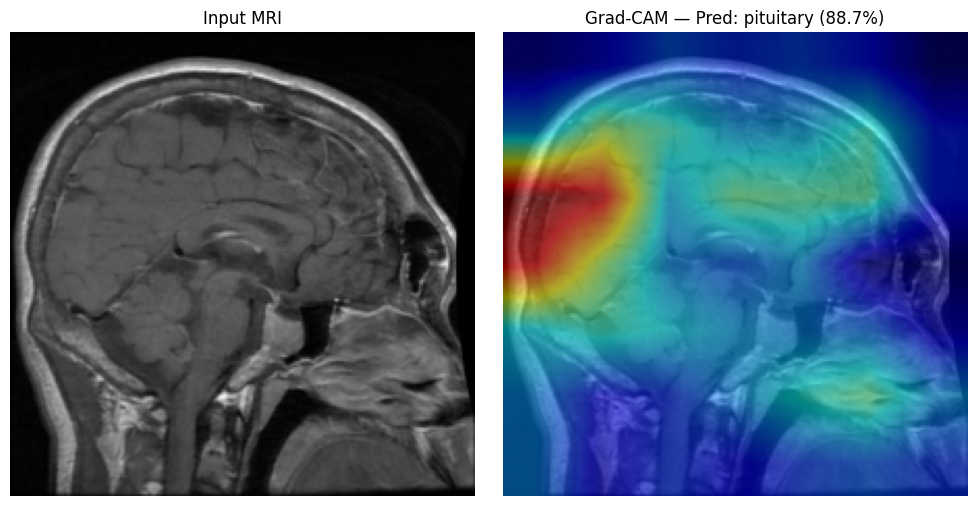

/tmp/ipykernel_1309/957849941.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=CLASS_NAMES, y=probs.cpu().numpy(), palette="viridis")


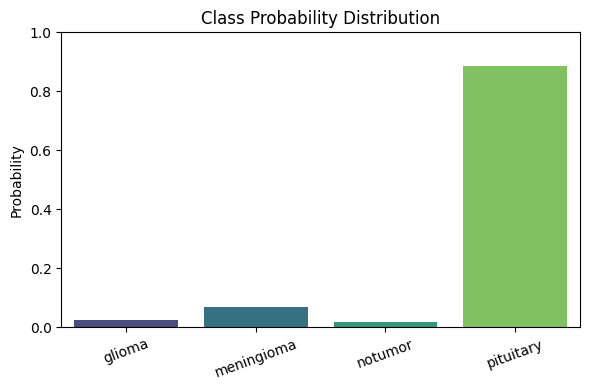

In [52]:
# ---- Grad-CAM for this image ----
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=[model.features[-1]])
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0]

rgb_img = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
heatmap = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_img); axes[0].axis("off"); axes[0].set_title("Input MRI")
axes[1].imshow(heatmap); axes[1].axis("off")
axes[1].set_title(f"Grad-CAM — Pred: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)")
plt.tight_layout()
plt.show()

# ---- Bar chart of class probabilities ----
plt.figure(figsize=(6, 4))
sns.barplot(x=CLASS_NAMES, y=probs.cpu().numpy(), palette="viridis")
plt.ylabel("Probability"); plt.ylim(0, 1)
plt.title("Class Probability Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 🚀 PHASE 6 — Deployment (Optional)
**Goal:** Save the trained model and generate a ready-to-run Streamlit web app for MRI upload → prediction → Grad-CAM heatmap.

Run the app locally (or via ngrok/Colab) with:
```bash
streamlit run app.py
```


In [53]:
# Save final artifacts (model weights + class names) for deployment
DEPLOY_DIR = "/content/deployment"
os.makedirs(DEPLOY_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(DEPLOY_DIR, "brain_tumor_model.pth"))
with open(os.path.join(DEPLOY_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)

print("Saved deployment artifacts to:", DEPLOY_DIR)
print(os.listdir(DEPLOY_DIR))

# Copy the best checkpoint back to Drive so it isn't lost when the Colab runtime resets
DRIVE_SAVE_DIR = "/content/drive/MyDrive/brain_tumor_deployment"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
shutil.copy(os.path.join(DEPLOY_DIR, "brain_tumor_model.pth"), DRIVE_SAVE_DIR)
shutil.copy(os.path.join(DEPLOY_DIR, "class_names.json"), DRIVE_SAVE_DIR)
print("Backed up model to Google Drive at:", DRIVE_SAVE_DIR)


Saved deployment artifacts to: /content/deployment
['class_names.json', 'brain_tumor_model.pth']
Backed up model to Google Drive at: /content/drive/MyDrive/brain_tumor_deployment


In [55]:
app_code = """
import json
import numpy as np
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

st.set_page_config(page_title="Brain Tumor MRI Classifier", layout="centered")

@st.cache_resource
def load_model():
    with open("class_names.json") as f:
        class_names = json.load(f)

    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(0.15),
        nn.Linear(256, len(class_names)),
    )
    model.load_state_dict(torch.load("brain_tumor_model.pth", map_location="cpu"))
    model.eval()
    return model, class_names

model, class_names = load_model()

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

st.title("Brain Tumor Detection from MRI")
st.write("Upload a brain MRI scan to classify the tumor type and view a Grad-CAM heatmap.")

uploaded_file = st.file_uploader("Upload MRI image", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)[0]
        pred_idx = int(torch.argmax(probs))
        confidence = float(probs[pred_idx])

    cam = GradCAM(model=model, target_layers=[model.features[-1]])
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0]

    rgb_img = np.array(image.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    heatmap = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    col1, col2 = st.columns(2)
    with col1:
        st.image(image, caption="Uploaded MRI", use_column_width=True)
    with col2:
        st.image(heatmap, caption="Grad-CAM Heatmap", use_column_width=True)

    st.subheader(f"Prediction: {class_names[pred_idx]}")
    st.write(f"Confidence: {confidence*100:.2f}%")

    st.bar_chart({class_names[i]: float(probs[i]) for i in range(len(class_names))})
"""

with open(os.path.join(DEPLOY_DIR, "app.py"), "w") as f:
    f.write(app_code)

requirements = "torch\ntorchvision\nstreamlit\npytorch-grad-cam\npillow\nnumpy\n"
with open(os.path.join(DEPLOY_DIR, "requirements.txt"), "w") as f:
    f.write(requirements)

shutil.copy(os.path.join(DEPLOY_DIR, "app.py"), DRIVE_SAVE_DIR)
shutil.copy(os.path.join(DEPLOY_DIR, "requirements.txt"), DRIVE_SAVE_DIR)
print("Streamlit app.py + requirements.txt written to:", DEPLOY_DIR, "and backed up to Drive.")
print("\nTo run locally:")
print("  cd", DRIVE_SAVE_DIR)
print("  pip install -r requirements.txt")
print("  streamlit run app.py")

Streamlit app.py + requirements.txt written to: /content/deployment and backed up to Drive.

To run locally:
  cd /content/drive/MyDrive/brain_tumor_deployment
  pip install -r requirements.txt
  streamlit run app.py


## ✅ Summary

| Phase | Output |
|---|---|
| 1. Data Acquisition | Clean, split (70/15/15), normalized dataset |
| 2. Augmentation | Balanced `DataLoader`s ready for training |
| 3. Architecture | EfficientNet-B0 transfer-learning model |
| 4. Training | `best_model.pth` + training history |
| 5. Evaluation | Accuracy / Precision / Recall / F1 / AUC + Confusion Matrix + Grad-CAM |
| 6. Deployment | `app.py` Streamlit web app + saved weights in Drive |

**Tips to push accuracy toward the 90–98% range:**
- Use a clean, well-labeled dataset (e.g. the Kaggle 4-class Brain Tumor MRI dataset) — this pipeline is highly sensitive to label noise.
- If accuracy plateaus, try: unfreezing more backbone blocks, increasing `IMG_SIZE` to 260 (EfficientNet-B2), enabling `k`-fold cross-validation, or adding test-time augmentation (TTA) at inference.
- Watch the train/val gap in the loss plot — a widening gap means overfitting; increase augmentation or dropout, or add more data.
